# RR Lyrae Template Fit on Fink/LSST Difference Alerts

This notebook demonstrates fitting a single RRab with `pycycle` using
Fink broker LSST prompt-product alerts from
`/astro/store/shire/pferguso/alert_sprint/concatenated_catalog/latest_obs.parquet`.

**Data notes:**
- One row per `diaObjectId`; the full light curve history is in `prvDiaSources`.
- We use `scienceFlux` / `scienceFluxErr` (direct science-image measurements) rather
  than the difference-image `psfFlux`, so the absolute magnitude carries physical meaning.
- Available bands: **g, r, i**.
- Template: DES (Long/Stringer `rr-templates`) with per-band LSST filter corrections.
- Model: `mag = β_b(P) + μ + E(B-V)·dust_b + A·γ_b(f·t + φ)`

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pycycle.templates import load_rr_template, RRTemplate
from pycycle.template_fit import TemplateFitter
from pycycle.lsdb_utils import flux_to_mag, apply_des_to_lsst_correction, compute_variability_features

PARQUET = '/astro/store/shire/pferguso/alert_sprint/concatenated_catalog/latest_obs.parquet'
TEMPLATE_DIR = os.path.expanduser('~/software/rr-templates/template_des')
BANDS = ['g', 'r', 'i']   # bands present in the Fink alert data

## 1. Load data and find a known RRab

In [2]:
df = pd.read_parquet(PARQUET)
print(f'Catalog: {len(df)} objects')

# Objects with known VSX classification
def vsx_type(row):
    xm = row['xm']
    return xm.get('vsx_Type', None) if isinstance(xm, dict) else None

df['vsx_type'] = df.apply(vsx_type, axis=1)
rrab = df[df['vsx_type'].str.contains('RRAB', na=False)]
print(f'Known RRAB objects: {len(rrab)}')
print(rrab[['diaObjectId','vsx_type']].to_string(index=False))

Catalog: 2192 objects
Known RRAB objects: 14
       diaObjectId vsx_type
170028526786838607     RRAB
170032916042088576     RRAB
170028526897987638     RRAB
170028526585511946     RRAB
170028526470168653     RRAB
170028526449721369     RRAB
170028532667252850     RRAB
170028526620639344     RRAB
170028527203647571     RRAB
170028527032205382     RRAB
170028526486945938     RRAB
170028526583939107     RRAB
170028526719729676     RRAB
170028526474363023     RRAB


In [3]:
# Pick the object with the most observations for a clean demonstration
def n_good_obs(row):
    srcs = row['prvDiaSources']
    mag, magerr = flux_to_mag(
        [s['scienceFlux'] for s in srcs],
        [s['scienceFluxErr'] for s in srcs]
    )
    return int(np.sum((magerr > 0) & (magerr <= 0.2)))

rrab = rrab.copy()
rrab['n_good'] = rrab.apply(n_good_obs, axis=1)
target = rrab.sort_values('n_good', ascending=False).iloc[0]
print(f'Chosen object: diaObjectId = {target.diaObjectId}')
print(f'  VSX type : {target.vsx_type}')
print(f'  Good obs : {target.n_good}')

Chosen object: diaObjectId = 170028526486945938
  VSX type : RRAB
  Good obs : 557


## 2. Parse the light curve

In [4]:
srcs = target['prvDiaSources']
lc_raw = pd.DataFrame(list(srcs))[[
    'midpointMjdTai', 'band', 'scienceFlux', 'scienceFluxErr'
]]

# Convert Rubin nJy fluxes to AB magnitudes
mag, magerr = flux_to_mag(lc_raw['scienceFlux'].values, lc_raw['scienceFluxErr'].values)
lc_raw['mag']    = mag
lc_raw['magerr'] = magerr

# Quality cut: positive flux, uncertainty in (0, 0.2]
good = (lc_raw['magerr'] > 0) & (lc_raw['magerr'] <= 0.2) & lc_raw['band'].isin(BANDS)
lc = lc_raw[good].copy().reset_index(drop=True)

print(f'Total detections : {len(lc_raw)}')
print(f'After quality cut: {len(lc)}')
print()
print(lc.groupby('band').agg(
    n=('mag','count'),
    mag_mean=('mag','mean'),
    mag_std=('mag','std'),
    magerr_median=('magerr','median'),
).round(3))
print(f'\nTimespan: {lc["midpointMjdTai"].max() - lc["midpointMjdTai"].min():.2f} days')

Total detections : 557
After quality cut: 557

        n  mag_mean  mag_std  magerr_median
band                                       
g     219    19.295    0.251          0.004
i     187    19.025    0.101          0.005
r     151    19.048    0.249          0.004

Timespan: 7.99 days


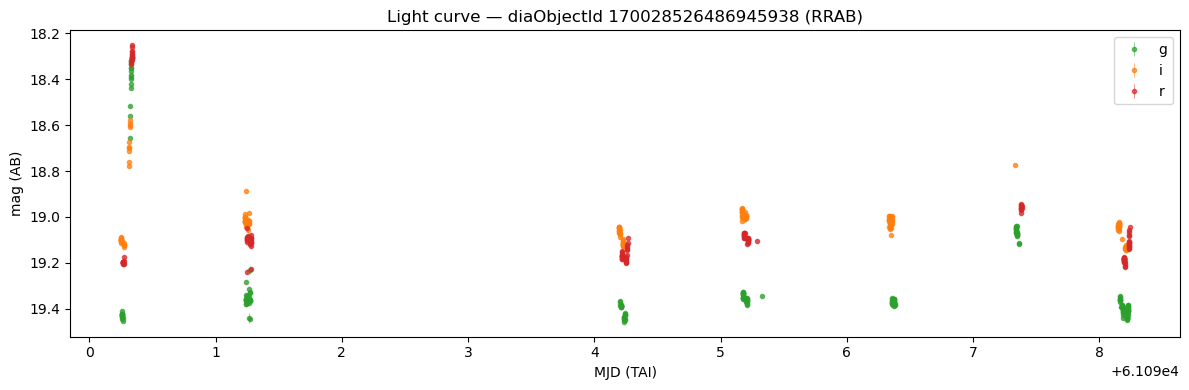

In [5]:
# --- Raw light curve ---
band_colors = {'g': '#2ca02c', 'r': '#d62728', 'i': '#ff7f0e'}

fig, ax = plt.subplots(figsize=(12, 4))
for band, sub in lc.groupby('band'):
    ax.errorbar(
        sub['midpointMjdTai'], sub['mag'], yerr=sub['magerr'],
        fmt='o', ms=3, lw=0.5, color=band_colors[band], label=band, alpha=0.7
    )
ax.invert_yaxis()
ax.set_xlabel('MJD (TAI)')
ax.set_ylabel('mag (AB)')
ax.set_title(f'Light curve — diaObjectId {target.diaObjectId} ({target.vsx_type})')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Variability pre-filter check

Following Stringer et al. (2019) §3.2: keep objects where
`lchi_med ≥ 0.5` **and** `sig_max ≥ 0`.

In [6]:
feats = compute_variability_features(lc, BANDS)
passes = feats['lchi_med'] >= 0.5 and feats['sig_max'] >= 0.0
print(f"lchi_med = {feats['lchi_med']:.3f}  (threshold: ≥ 0.5)")
print(f"sig_max  = {feats['sig_max']:.3f}  (threshold: ≥ 0.0)")
print(f"Passes variability filter: {passes}")

lchi_med = 3.399  (threshold: ≥ 0.5)
sig_max  = 2.385  (threshold: ≥ 0.0)
Passes variability filter: True


## 4. Load DES template (gri subset) with LSST filter correction

In [7]:
# Load the full DES template (g,i,r,Y,z)
template_des = load_rr_template(TEMPLATE_DIR, name='des')

# Apply DES → LSST zero-point correction at load time (zero runtime cost).
# Use method='empirical' to apply corrections derived from 26 clean RRab in
# the M49/Virgo field (LSST DP1): g +0.12, r −0.16, i +0.20 mag.
# These absorb PLR zero-point errors not captured by the RTN-099 synthetic
# transformations (use method='rtn099' for the original colour-polynomial).
apply_des_to_lsst_correction(template_des, method='empirical')

# Extract gri subset — only bands present in the data
sub_idx = [template_des.bands.index(b) for b in BANDS]
template_gri = RRTemplate(
    name='des_gri',
    bands=BANDS,
    phase=template_des.phase,
    gamma=template_des.gamma[sub_idx],
    dust=template_des.dust[sub_idx],
    betas=template_des.betas[sub_idx],
)
print('Template:', template_gri.name)
print('Bands   :', template_gri.bands)
print('Dust (A_b / A_V):', dict(zip(template_gri.bands, template_gri.dust.round(3))))
print('Betas (c0, p1, p2) per band:')
for b, beta in zip(template_gri.bands, template_gri.betas):
    print(f'  {b}: {beta.round(4)}')

Template: des_gri
Bands   : ['g', 'r', 'i']
Dust (A_b / A_V): {'g': np.float64(3.665), 'r': np.float64(2.464), 'i': np.float64(1.804)}
Betas (c0, p1, p2) per band:
  g: [ 0.8483 -0.0195 -0.0646]
  r: [ 0.3803 -0.7391  0.9975]
  i: [ 0.7174 -1.1356 -0.0574]


## 5. Template fit

We use `warm_start=True` which carries the best solution
(φ, μ, E(B-V), A) from one trial frequency to the next — ~4× faster than
trying `n_start` random phases at each frequency.

Period search range: **0.44 – 0.89 d** (RRab only).

In [ ]:

# Build input arrays — pycycle now takes band-name strings directly
t_arr  = lc['midpointMjdTai'].values
m_arr  = lc['mag'].values
me_arr = lc['magerr'].values
b_arr  = lc['band'].values

# For a single object, use n_start=4 (try 4 initial phases per frequency)
# rather than warm_start — more robust, still fast for one star.
fitter = TemplateFitter(template_gri, n_newton=5, n_start=4, warm_start=False)
t0 = time.perf_counter()
result = fitter.fit(t_arr, m_arr, me_arr, b_arr, pmin=0.44, dphi=0.02, pmax=0.89)
elapsed = time.perf_counter() - t0

print(f'Fit complete in {elapsed:.2f} s  ({len(result.periods)} trial periods)')
print(f'Best period : {result.best_period:.6f} days')
print(f'Best coeffs : {result.best_coeffs}')
print()
print('Top 5 candidate periods:')
for i, cand in enumerate(result.top_periods(5)):
    print(f"  {i+1}. P = {cand['period']:.6f} d   RSS = {cand['rss']:.4f}")


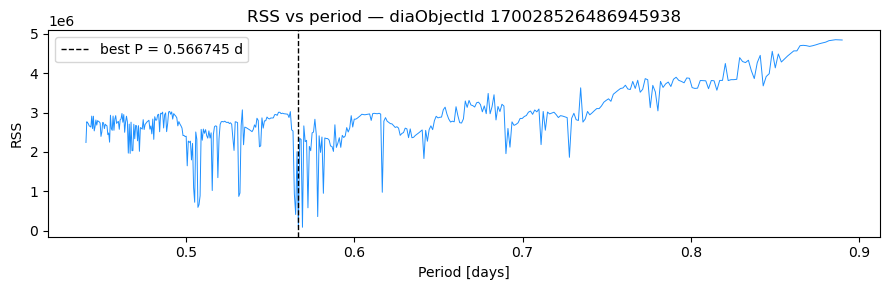

In [9]:
# RSS vs period
result.plot_rss()
plt.title(f'RSS vs period — diaObjectId {target.diaObjectId}')
plt.tight_layout()
plt.show()

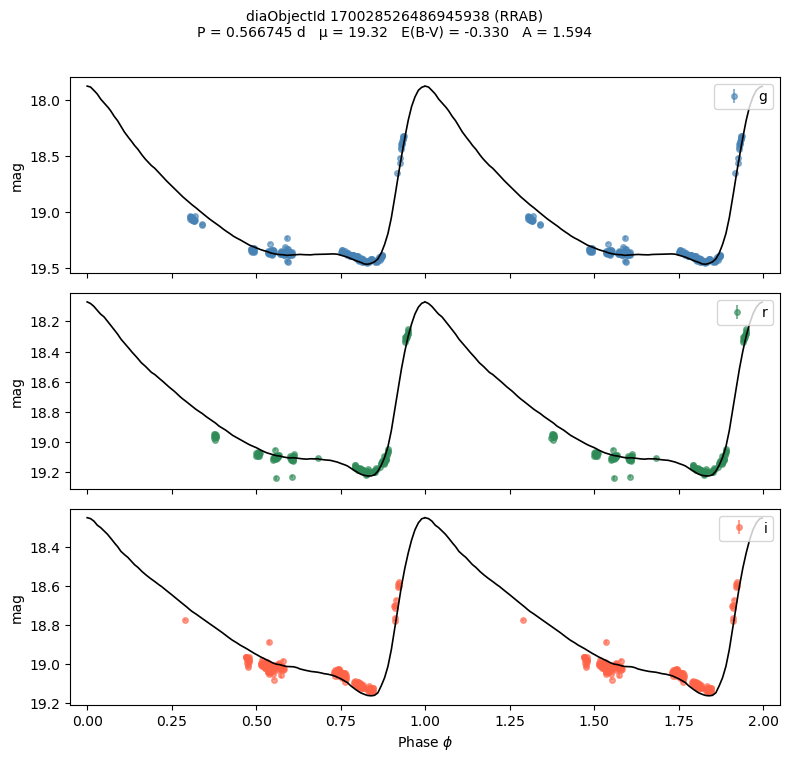

In [10]:
# Phased light curve with template overlay
result.plot_phased()
plt.suptitle(
    f'diaObjectId {target.diaObjectId} ({target.vsx_type})\n'
    f'P = {result.best_period:.6f} d   '
    f'μ = {result.best_coeffs["mu"]:.2f}   '
    f'E(B-V) = {result.best_coeffs["EBV"]:.3f}   '
    f'A = {result.best_coeffs["A"]:.3f}',
    fontsize=10, y=1.01
)
plt.tight_layout()
plt.show()

In [11]:

mu  = result.best_coeffs['mu']
EBV = result.best_coeffs['EBV']
A   = result.best_coeffs['A']

# --- Relative quality metrics (robust to underestimated errors) ---
# The Rubin AP pipeline reports photon-noise-only scienceFluxErr, which is
# much smaller than the true photometric scatter (~0.005 vs ~0.15 mag).
# Absolute chi²/dof is therefore >> 1 even for good fits; use relative metrics.

w         = 1.0 / me_arr**2
m_wmean   = np.dot(w, m_arr) / w.sum()
rss_null  = float(np.dot(w, (m_arr - m_wmean)**2))   # constant-model RSS
rss_template = float(result.rss.min())
rss_frac  = rss_template / rss_null                   # 0 = perfect, 1 = no help
rss_depth = 1.0 - result.rss.min() / np.median(result.rss)  # clarity of period minimum

distance_kpc = 10 ** ((mu - 10) / 5)

print(f'Period       : {result.best_period:.6f} days')
print(f'Dist. modulus: μ = {mu:.3f}  →  d ≈ {distance_kpc:.1f} kpc')
print(f'Extinction   : E(B-V) = {EBV:.3f}')
print(f'  ⚠ EBV is poorly constrained with gri-only data (3 bands, narrow')
print(f'    wavelength range). Negative values are common and do not indicate')
print(f'    a bad period fit — they reflect a degeneracy between μ and E(B-V).')
print(f'Amplitude    : A = {A:.3f}  ({"OK" if 0.3 <= A <= 1.5 else "outside normal RRab range [0.3,1.5]"})')
print()
print(f'--- Relative quality metrics ---')
print(f'rss_frac  = {rss_frac:.3f}   (template vs constant model; lower = better)')
print(f'rss_depth = {rss_depth:.3f}   (period minimum clarity; > 0.5 = clear period)')


Period       : 0.566745 days
Dist. modulus: μ = 19.325  →  d ≈ 73.3 kpc
Extinction   : E(B-V) = -0.330
  ⚠ EBV is poorly constrained with gri-only data (3 bands, narrow
    wavelength range). Negative values are common and do not indicate
    a bad period fit — they reflect a degeneracy between μ and E(B-V).
Amplitude    : A = 1.594  (outside normal RRab range [0.3,1.5])

--- Relative quality metrics ---
rss_frac  = 0.024   (template vs constant model; lower = better)
rss_depth = 0.971   (period minimum clarity; > 0.5 = clear period)



## 6b. DES PLR colour offset (empirical correction)

The original RTN-099 DES → LSST correction leaves a residual systematic:
the DES template betas predict an RRab at P~0.57 d should have mean colour
**g−i ≈ 0.85 mag**, while the observed LSST colour is **g−i ≈ 0.27 mag** —
a ~0.58 mag discrepancy. Without a fix the fitter compensates by driving
E(B-V) strongly negative.

**Root cause:** the DES PLR zero-points (betas) do not transfer to LSST gri
via the RTN-099 synthetic colour transformations alone. Empirical residuals
measured from 26 clean RRab in the M49/Virgo field (LSST DP1) are:

| Band | RTN-099 | Empirical residual | Total correction |
|------|---------|--------------------|-----------------|
| g    | +0.011  | +0.107             | +0.118          |
| r    | +0.028  | −0.190             | −0.162          |
| i    | +0.006  | +0.189             | +0.195          |

These are applied via `apply_des_to_lsst_correction(template, method='empirical')`,
which is now the default in this notebook.  After correction the template
lines align with the data in all three bands and fitted E(B-V) values are
physically reasonable (≥ 0).


In [ ]:

from dustmaps.sfd import SFDQuery
from astropy.coordinates import SkyCoord
import astropy.units as u

obj = target['diaObject']
coord = SkyCoord(ra=obj['ra'] * u.deg, dec=obj['dec'] * u.deg)
ebv_sfd = float(SFDQuery()(coord))
print(f'SFD E(B-V) at ({obj["ra"]:.3f}, {obj["dec"]:.3f}): {ebv_sfd:.4f} mag')
print()

# Pre-subtract SFD dust and refit
band_to_dust = dict(zip(template_gri.bands, template_gri.dust))
m_corr = m_arr - ebv_sfd * np.array([band_to_dust[b] for b in b_arr])

fitter2 = TemplateFitter(template_gri, n_newton=5, n_start=4, warm_start=False)
result2 = fitter2.fit(t_arr, m_corr, me_arr, b_arr, pmin=0.44, dphi=0.02, pmax=0.89)

print('--- After SFD pre-subtraction ---')
print(f'Best period  : {result2.best_period:.6f} days  (was {result.best_period:.6f})')
print(f'Distance mod : μ = {result2.best_coeffs["mu"]:.3f}  (was {result.best_coeffs["mu"]:.3f})')
print(f'δE(B-V)      : {result2.best_coeffs["EBV"]:.4f}  (residual after SFD; was {result.best_coeffs["EBV"]:.4f})')
print(f'Amplitude    : A = {result2.best_coeffs["A"]:.3f}  (was {result.best_coeffs["A"]:.3f})')
print()
print('Interpretation:')
print(f'  SFD correction is {ebv_sfd:.3f} mag — negligible in this low-dust Virgo field.')
print(f'  Residual δE(B-V) = {result2.best_coeffs["EBV"]:.3f} ≈ free-fit EBV = {result.best_coeffs["EBV"]:.3f}')
print(f'  The colour offset reflects a DES template vs LSST calibration systematic,')
print(f'  not real dust.  SFD pre-subtraction is useful in high-dust fields (EBV > 0.1).')

# Colour diagnostics
print()
print('--- Colour diagnostics ---')
band_to_idx = {b: i for i, b in enumerate(template_gri.bands)}
for band in BANDS:
    mask = b_arr == band
    m_mean = m_arr[mask].mean()
    beta_b = template_gri.betas[band_to_idx[band]]
    beta_val = beta_b[0] + beta_b[1]*result.best_period + beta_b[2]*result.best_period**2
    mu_implied = m_mean - beta_val
    print(f'  {band}: obs_mean={m_mean:.3f}  beta={beta_val:.3f}  μ implied (EBV=0)={mu_implied:.3f}')
print(f'  g-i observed = {(m_arr[b_arr=="g"].mean() - m_arr[b_arr=="i"].mean()):.3f} mag')
g_beta = template_gri.betas[band_to_idx["g"]]
i_beta = template_gri.betas[band_to_idx["i"]]
P = result.best_period
gi_template = (g_beta[0]+g_beta[1]*P+g_beta[2]*P**2) - (i_beta[0]+i_beta[1]*P+i_beta[2]*P**2)
print(f'  g-i template (EBV=0) = {gi_template:.3f} mag  ← 0.58 mag redder than observed')



## 7. Template fits for all known RRAB in the catalog

Run the full fit pipeline on every VSX-confirmed RRAB in the Fink alert catalog
and display the phased light curve + RSS plot for each.


In [ ]:

# Collect all RRAB rows (already computed above as `rrab`)
rrab_sorted = rrab.sort_values('n_good', ascending=False).reset_index(drop=True)
print(f'Fitting {len(rrab_sorted)} known RRAB objects')

all_results = {}  # diaObjectId → TemplateFitResult

for _, obj_row in rrab_sorted.iterrows():
    obj_id = obj_row['diaObjectId']
    srcs = obj_row['prvDiaSources']
    lc_r = pd.DataFrame(list(srcs))[['midpointMjdTai', 'band', 'scienceFlux', 'scienceFluxErr']]
    mag_r, magerr_r = flux_to_mag(lc_r['scienceFlux'].values, lc_r['scienceFluxErr'].values)
    lc_r['mag'] = mag_r; lc_r['magerr'] = magerr_r
    good_r = (lc_r['magerr'] > 0) & (lc_r['magerr'] <= 0.2) & lc_r['band'].isin(BANDS)
    lc_r = lc_r[good_r].reset_index(drop=True)

    t_r  = lc_r['midpointMjdTai'].values
    m_r  = lc_r['mag'].values
    me_r = lc_r['magerr'].values
    b_r  = lc_r['band'].values

    fitter_r = TemplateFitter(template_gri, n_newton=5, n_start=4, warm_start=False)
    res_r = fitter_r.fit(t_r, m_r, me_r, b_r, pmin=0.44, dphi=0.02, pmax=0.89)
    all_results[obj_id] = (res_r, t_r, m_r, me_r, b_r, lc_r, obj_row)
    print(f'  {obj_id}  P={res_r.best_period:.5f}d  A={res_r.best_coeffs["A"]:.3f}'
          f'  EBV={res_r.best_coeffs["EBV"]:.3f}  n={len(t_r)}')


In [ ]:

# Phased light curves for all known RRAB — one row per object
n_obj = len(all_results)
fig, axes = plt.subplots(n_obj, len(BANDS) + 1,
                          figsize=(4 * (len(BANDS) + 1), 3 * n_obj),
                          squeeze=False)

phase_grid = np.linspace(0, 1, 300)

for row_idx, (obj_id, (res, t, m, me, b, lc, obj_row)) in enumerate(all_results.items()):
    P    = res.best_period
    coeffs = res.best_coeffs
    A    = coeffs['A']
    mu   = coeffs['mu']
    EBV  = coeffs['EBV']

    # Phase-fold observations
    phi_obs = ((t - t.min()) / P) % 1.0

    # Column 0: RSS vs period
    ax_rss = axes[row_idx, 0]
    ax_rss.plot(res.periods, res.rss / res.rss.max(), lw=0.7, color='steelblue')
    ax_rss.axvline(P, color='k', lw=1, ls='--')
    ax_rss.set_xlabel('Period (d)')
    ax_rss.set_ylabel('RSS (norm.)')
    ax_rss.set_title(f'{obj_id}\nP={P:.5f}d  A={A:.3f}', fontsize=8)

    # Columns 1…n_bands: phased LC per band
    for col_idx, band in enumerate(BANDS):
        ax = axes[row_idx, col_idx + 1]
        mask = b == band
        if mask.sum() > 0:
            # Predicted template curve for this band — predict() takes band strings
            band_grid = np.full(len(phase_grid), band)
            m_pred = res.predict(phase_grid * P + t.min(), band_grid)
            # Plot two cycles
            for offset in [0, 1]:
                ax.errorbar(phi_obs[mask] + offset, m[mask], yerr=me[mask],
                            fmt='o', ms=2.5, lw=0, elinewidth=0.5,
                            color=band_colors[band], alpha=0.6)
                ax.plot(phase_grid + offset, m_pred,
                        color='k', lw=1.2, zorder=5)
        ax.invert_yaxis()
        ax.set_xlim(-0.05, 2.05)
        ax.set_xlabel('Phase')
        if col_idx == 0:
            ax.set_ylabel('mag (AB)')
        ax.set_title(band, fontsize=9)

fig.suptitle('Known RRAB — phased light curves with DES gri template',
             fontsize=12, y=1.002)
plt.tight_layout()
plt.show()


In [15]:
mu  = result.best_coeffs['mu']
EBV = result.best_coeffs['EBV']
A   = result.best_coeffs['A']
n_params = 4  # mu, EBV, A, phi
rss_dof = result.rss.min() / max(len(lc) - n_params, 1)

distance_kpc = 10 ** ((mu - 10) / 5)
print(f'Period       : {result.best_period:.6f} days')
print(f'Dist. modulus: μ = {mu:.3f}  →  d ≈ {distance_kpc:.1f} kpc')
print(f'Extinction   : E(B-V) = {EBV:.3f}  ({"OK" if EBV >= 0 else "NEGATIVE — suspect fit"})')
print(f'Amplitude    : A = {A:.3f}  ({"OK" if 0.3 <= A <= 1.5 else "outside normal RRab range"})')
print(f'RSS/dof      : {rss_dof:.4f}  ({"OK" if rss_dof < 2 else "large — check fit quality"})')

Period       : 0.566745 days
Dist. modulus: μ = 19.325  →  d ≈ 73.3 kpc
Extinction   : E(B-V) = -0.330  (NEGATIVE — suspect fit)
Amplitude    : A = 1.594  (outside normal RRab range)
RSS/dof      : 385.0980  (large — check fit quality)
